In [15]:
%pip install --upgrade perceptron pydantic pillow --quiet


DEPRECATION: Loading egg at /home/shared/common/envs/genesis_pretrain_nightly/lib/python3.12/site-packages/flash_attn_3-3.0.0b1-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
Note: you may need to restart the kernel to use updated packages.


## Configure the client
Authenticate and load the sample image.


In [16]:
from pathlib import Path

from IPython.display import Image as IPyImage, display

from cookbook.utils import cookbook_asset
from perceptron import configure, pydantic_format, perceive, image, text

# configure() reads PERCEPTRON_API_KEY from the environment.
configure(provider="perceptron")

SCENE_PATH = cookbook_asset("capabilities", "qna", "studio_scene.webp")
if not SCENE_PATH.exists():
    raise FileNotFoundError(f"Missing asset: {SCENE_PATH}")


## Structured output with Pydantic
Define a Pydantic model and the SDK automatically converts it to a JSON schema for constrained decoding.


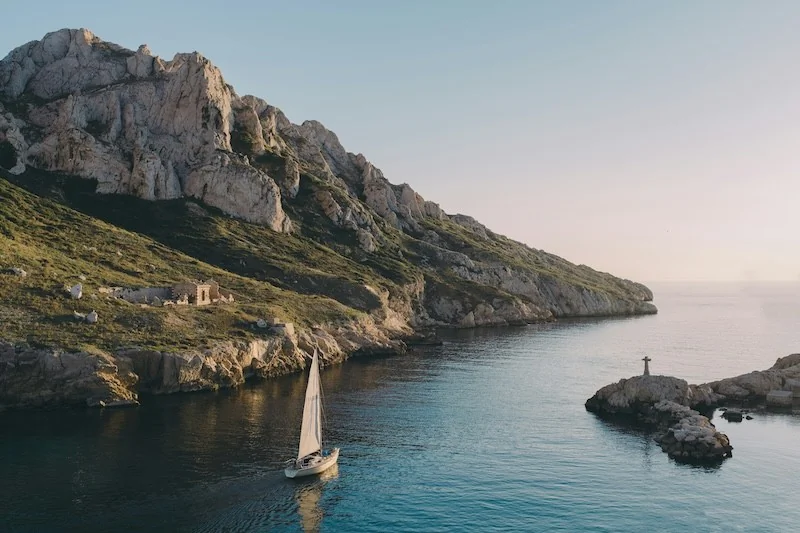

AuthError: Unauthorized

In [17]:
from pydantic import BaseModel, Field
from typing import Literal


class SceneAnalysis(BaseModel):
    """Structured scene analysis output."""

    scene_type: str = Field(description="Category: outdoor, indoor, urban, nature")
    main_subjects: list[str] = Field(description="Primary objects in the scene")
    mood: Literal["calm", "energetic", "dramatic", "peaceful", "tense"]
    time_of_day: Literal["morning", "afternoon", "evening", "night", "unknown"]


@perceive(response_format=pydantic_format(SceneAnalysis))
def analyze_scene(img_path):
    return image(img_path) + text("Analyze this scene.")


display(IPyImage(filename=str(SCENE_PATH), width=400))
result = analyze_scene(str(SCENE_PATH))

# Parse directly into the Pydantic model
analysis = SceneAnalysis.model_validate_json(result.text)
print(f"Scene type: {analysis.scene_type}")
print(f"Subjects: {analysis.main_subjects}")
print(f"Mood: {analysis.mood}")
print(f"Time: {analysis.time_of_day}")
